In [246]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chi2, norm, chisquare, kstest, expon, uniform

# Simulation and estimation in a Markov model of breast cancer

# Part 1: A discrete-time model

## Task 1

In [247]:
P  = np.array([
    [0.9915, 0.005,  0.0025, 0,     0.001],
    [0,      0.986,  0.005,  0.004, 0.005],
    [0,      0,      0.992,  0.003, 0.005],
    [0,      0,      0,      0.991, 0.009],
    [0,      0,      0,      0,     1.0]
])

n = 1000
p0 = [1,0,0,0,0]

In [248]:
def sim_liftime_women(n):
    death_state = 4
    life_times = []
    local = []

    for _ in range(n):
        state = 0
        t = 0

        had_local = False
        while state != death_state:
            if state in [1,3]:
                had_local = True
            
            state = np.random.choice(np.arange(5), p = P[state])

            t += 1

        life_times.append(t)
        local.append(had_local)
    
    return np.array(life_times), local


In [249]:
np.random.seed(42)
n = 1000
life_times, local = sim_liftime_women(n)
np.mean(life_times), np.sum(local)/n

(np.float64(265.035), np.float64(0.712))

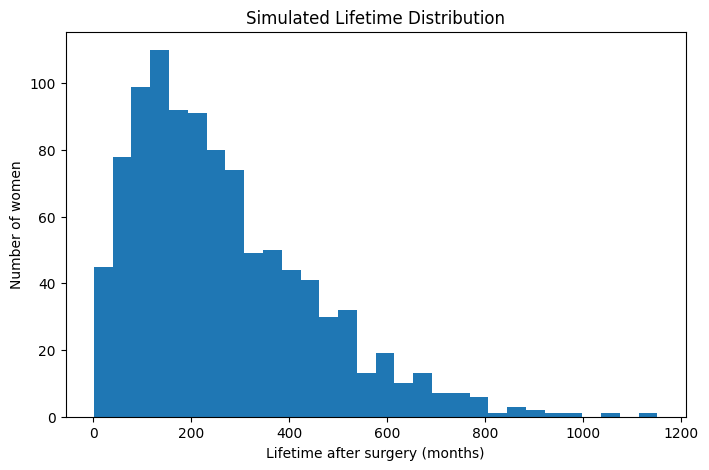

In [250]:
# Histogram
plt.figure(figsize=(8, 5))
plt.hist(life_times, bins=30)
plt.xlabel("Lifetime after surgery (months)")
plt.ylabel("Number of women")
plt.title("Simulated Lifetime Distribution")
plt.show()

## Task 2

In [251]:

def simulate_women(n, max_t=1200):

    n_states = 5
    death_state = n_states - 1

    lifetimes = []
    had_local = np.zeros(n, dtype=bool)

    counts = np.zeros((max_t + 1, n_states), dtype=int)

    states = np.zeros(n, dtype=int)
    alive = np.ones(n, dtype=bool)

    counts[0, 0] = n

    for t in range(1, max_t + 1):

        for i in np.where(alive)[0]:

            # transition first
            new_state = np.random.choice(
                n_states,
                p=P[states[i]]
            )

            states[i] = new_state

            # record local recurrence AFTER transition
            if new_state in [1, 3]:
                had_local[i] = True

            # check death
            if new_state == death_state:
                alive[i] = False
                lifetimes.append(t)

        # store distribution
        counts[t] = np.bincount(states, minlength=n_states)

        # early stopping
        if not alive.any():
            counts[t:] = counts[t]
            break

    return np.array(lifetimes), had_local, counts

In [252]:
np.random.seed(42)
n = 1000
life_times, had_local, counts = simulate_women(n, max_t=1400)
np.mean(life_times), np.sum(had_local)/n

(np.float64(263.974), np.float64(0.707))

In [253]:
emp_state_120 = counts[120,:]

In [254]:
p0 = np.array([1, 0, 0, 0, 0])
n = 1000
times = [120]  # months

print("\nAnalytical state distributions:")
for t in times:
    Pt = np.linalg.matrix_power(P, t)
    pt_120 = (p0 @ Pt)*n

    print(f"\nt = {t} months")
    print("Theorical state distribution")
    print(f"{pt_120}")



Analytical state distributions:

t = 120 months
Theorical state distribution
[359.02626821 158.95603979 166.08689731  67.74149395 248.18930075]


In [255]:
_, p_value_chi = chisquare(f_obs=emp_state_120, f_exp=pt_120)
print(f"Results of chi square test {p_value_chi}")

Results of chi square test 0.513404950761478


## Task 3

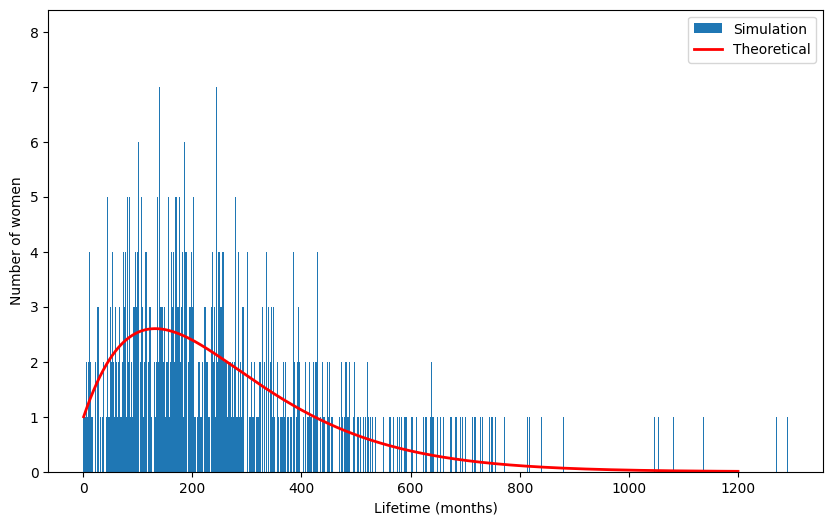

In [256]:

# initial distribution
pi = np.array([1, 0, 0, 0])

# transient and absorption parts
Q = P[:-1, :-1]
r = P[:-1, -1]

# theoretical pdf
pdf = np.zeros(1200)

for t in range(1200):
    Qt = np.linalg.matrix_power(Q, t)
    pdf[t] = pi @ Qt @ r   # scalar

expected_counts = len(life_times) * pdf

# plot
plt.figure(figsize=(10,6))

plt.hist(
    life_times,
    bins=np.arange(0.5, max(life_times)+1.5, 1),
    label="Simulation"
)

months = np.arange(1, 1201)

plt.plot(
    months,
    expected_counts,
    'r',
    lw=2,
    label="Theoretical"
)

plt.xlabel("Lifetime (months)")
plt.ylabel("Number of women")
plt.legend()
plt.show()
